In [ ]:
%pip install 'stable-baselines3[extra]'
%pip install sb3-contrib

In [2]:
import os
import time

import gymnasium as gym
from stable_baselines3.common.monitor import Monitor

from blackjack_env.wrappers import ShiftWrapper, SafeV1ActionWrapper
from blackjack_env.agent_utils.sb3_ppo import test_env_PPO

log_dir = os.path.abspath(f"../results/sb3_blackjack_{int(time.time())}")
os.makedirs(log_dir, exist_ok=True)


def make_env(log_dir: str, seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))
    env.reset(seed=seed)
    return env


def make_evaluation_env(seed: int) -> gym.Env:
    env = gym.make("Blackjack4game-v1", render_mode=None)
    env = ShiftWrapper(env)
    env = SafeV1ActionWrapper(env)
    env.reset(seed=seed)
    return env

In [3]:
# ppo_kwargs_base = dict(
#     learning_rate=3e-4,
#     n_steps=2048,
#     batch_size=256,
#     n_epochs=10,
#     gamma=0.99,
#     gae_lambda=0.95,
#     clip_range=0.2,
#     ent_coef=0.01,
#     vf_coef=0.5,
#     max_grad_norm=0.5,
# )

# ppo_kwargs_stable_slow = dict(
#     learning_rate=1e-4,
#     n_steps=4096,
#     batch_size=256,
#     n_epochs=10,
#     gamma=0.995,
#     gae_lambda=0.95,
#     clip_range=0.15,
#     ent_coef=0.005,
# )

# ppo_kwargs_fast = dict(
#     learning_rate=1e-3,
#     n_steps=1024,
#     batch_size=128,
#     n_epochs=5,
#     gamma=0.99,
#     gae_lambda=0.9,
#     clip_range=0.2,
#     ent_coef=0.02,
# )

# ppo_kwargs_explore = dict(
#     learning_rate=3e-4,
#     n_steps=2048,
#     batch_size=256,
#     n_epochs=10,
#     ent_coef=0.05,  # większa entropia
#     gamma=0.99,
#     gae_lambda=0.95,
# )

# HP_SETS = [
#     (
#         "fast",
#         dict(
#             learning_rate=1e-3,
#             n_steps=1024,
#             batch_size=1024,
#             n_epochs=5,
#             gamma=0.99,
#             gae_lambda=0.90,
#             clip_range=0.20,
#             ent_coef=0.01,
#             vf_coef=0.5,
#             max_grad_norm=0.5,
#         ),
#     ),
#     (
#         "base_fast",
#         dict(
#             learning_rate=3e-4,
#             n_steps=2048,
#             batch_size=1024,
#             n_epochs=5,
#             gamma=0.99,
#             gae_lambda=0.95,
#             clip_range=0.20,
#             ent_coef=0.01,
#             vf_coef=0.5,
#             max_grad_norm=0.5,
#         ),
#     ),
#     (
#         "explore_fast",
#         dict(
#             learning_rate=3e-4,
#             n_steps=2048,
#             batch_size=1024,
#             n_epochs=5,
#             gamma=0.99,
#             gae_lambda=0.95,
#             clip_range=0.20,
#             ent_coef=0.03,  # trochę więcej eksploracji, bez przesady
#             vf_coef=0.5,
#             max_grad_norm=0.5,
#         ),
#     ),
# ]

In [4]:
BASE = dict(
    policy="MultiInputPolicy",
    verbose=1,
    n_runs=10,
    run_timesteps=200_000,
    eval_freq=1_000,
    n_eval_episodes=20,
    base_seed=42,
)

PPO_BASE = dict(
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=256,  # <= n_steps
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.20,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
)

HP_SETS = [
    # 1) "fast": tylko większy learning rate (szybciej się uczy, ryzyko niestabilności)
    (
        "fast_lr",
        {
            **PPO_BASE,
            **dict(
                learning_rate=1e-3,
            ),
        },
    ),
    # 2) "base": baza (punkt odniesienia)
    ("base", {**PPO_BASE}),
    # 3) "explore": tylko większa entropia (więcej eksploracji)
    (
        "explore",
        {
            **PPO_BASE,
            **dict(
                ent_coef=0.03,
            ),
        },
    ),
]

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== fast_lr ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.19     |
|    ep_rew_mean     | -0.172   |
| time/              |          |
|    fps             | 826      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.22         |
|    ep_rew_mean          | -0.0292      |
| time/                   |              |
|    fps                  | 806          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0106482785 |
|    clip_fraction        | 0.0578       |
|    clip_range           | 0.2         

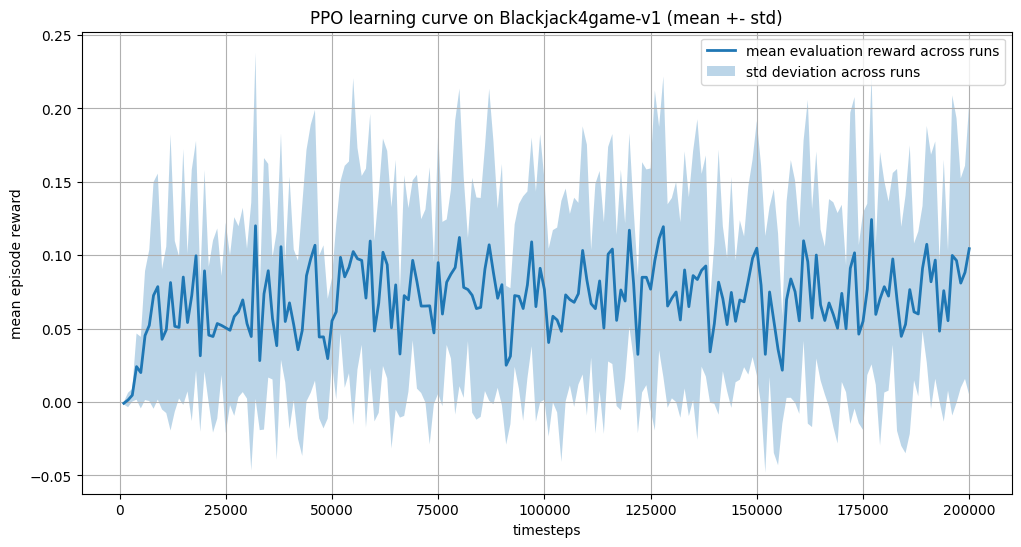

/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jakseluz/nauka/VI_semestr/inteligencja_obliczeniowa_w_analizie_danych_cyfrowych/.venv/lib/python3.14/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



=== base ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.19     |
|    ep_rew_mean     | -0.172   |
| time/              |          |
|    fps             | 957      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.22         |
|    ep_rew_mean          | -0.0402      |
| time/                   |              |
|    fps                  | 853          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0011444995 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |


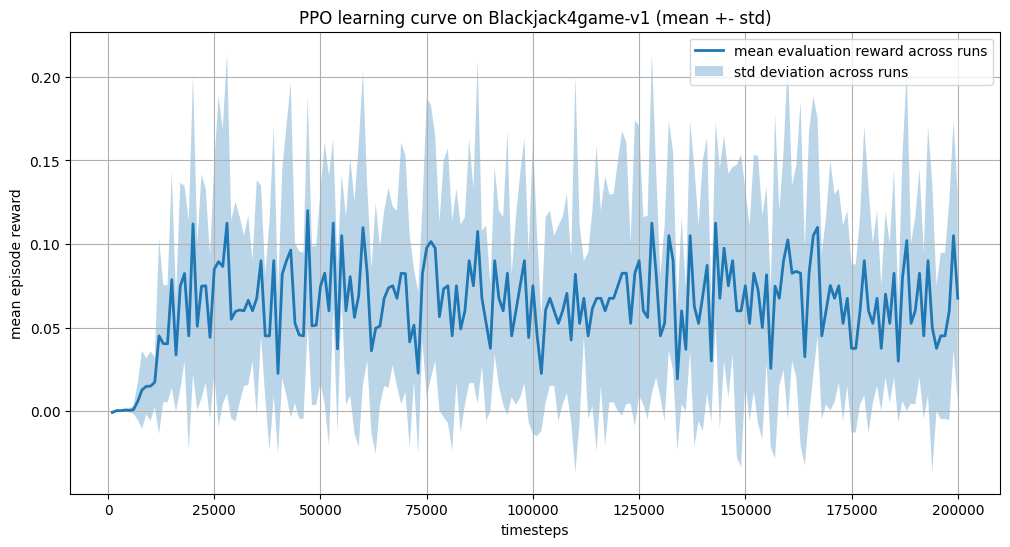


=== explore ===
Starting run 1/10 with seed 42...
Using cuda device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.19     |
|    ep_rew_mean     | -0.172   |
| time/              |          |
|    fps             | 947      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 3.22         |
|    ep_rew_mean          | -0.0402      |
| time/                   |              |
|    fps                  | 926          |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0011407364 |
|    clip_fraction        | 0.000195     |
|    clip_range           | 0.2         

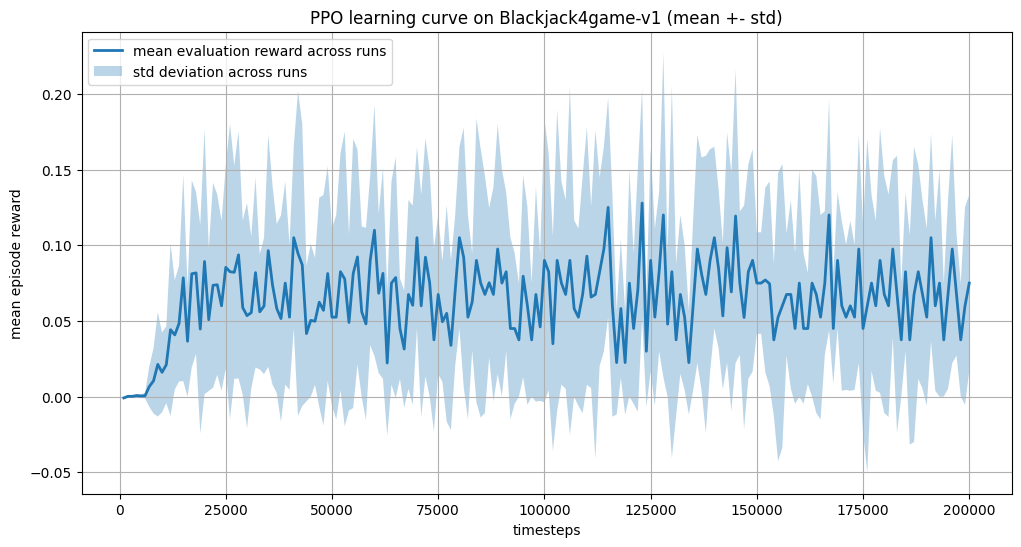

In [5]:
for name, hp in HP_SETS:
    run_log_dir = os.path.join(log_dir, name)
    os.makedirs(run_log_dir, exist_ok=True)

    env_train = make_env(log_dir=run_log_dir, seed=BASE["base_seed"])
    env_eval = make_evaluation_env(seed=BASE["base_seed"] + 10_000)

    print(f"\n=== {name} ===")
    test_env_PPO(
        env_train=env_train,
        env_eval=env_eval,
        **BASE,
        **hp,
    )